✅ GPU found: Tesla T4

🚀 Starting CPU vs. GPU performance benchmark...

--- Testing Matrix Size: 256x256 ---
🧠 CPU Time: 0.0972 seconds
💪 GPU Time: 0.0002 seconds

--- Testing Matrix Size: 512x512 ---
🧠 CPU Time: 0.0165 seconds
💪 GPU Time: 0.0065 seconds

--- Testing Matrix Size: 1024x1024 ---
🧠 CPU Time: 0.0903 seconds
💪 GPU Time: 0.0039 seconds

--- Testing Matrix Size: 2048x2048 ---
🧠 CPU Time: 0.2513 seconds
💪 GPU Time: 0.0064 seconds

--- Testing Matrix Size: 4096x4096 ---
🧠 CPU Time: 1.3122 seconds
💪 GPU Time: 0.0478 seconds

📊 Benchmark Results Summary
Matrix Size  CPU Time (s)  GPU Time (s)    Speedup
    256x256      0.097214      0.000206 472.473928
    512x512      0.016453      0.006458   2.547643
  1024x1024      0.090285      0.003881  23.262055
  2048x2048      0.251345      0.006361  39.514824
  4096x4096      1.312241      0.047784  27.461873


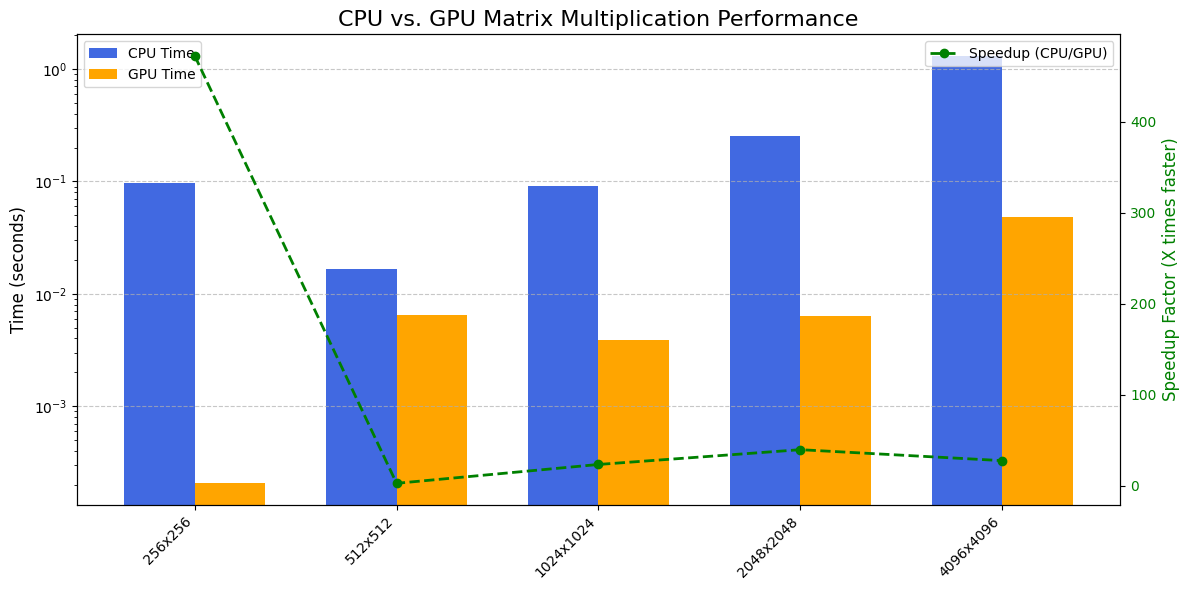

In [1]:
import torch
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
# We will test a range of matrix sizes to see how performance scales.
MATRIX_SIZES = [256, 512, 1024, 2048, 4096]

# --- Setup ---
# Check if a GPU is available and set the device accordingly.
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ GPU found: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("⚠️ No GPU found, all operations will run on the CPU.")

results = []

print("\n🚀 Starting CPU vs. GPU performance benchmark...")

# --- Main Loop ---
# Iterate through each matrix size to perform the benchmark.
for size in MATRIX_SIZES:
    print(f"\n--- Testing Matrix Size: {size}x{size} ---")

    # Prepare data on the CPU
    cpu_matrix_a = torch.randn(size, size)
    cpu_matrix_b = torch.randn(size, size)

    # 1. CPU Benchmark
    start_time = time.time()
    result_cpu = torch.matmul(cpu_matrix_a, cpu_matrix_b)
    cpu_time = time.time() - start_time
    print(f"🧠 CPU Time: {cpu_time:.4f} seconds")

    # 2. GPU Benchmark
    gpu_time = -1.0 # Default value if no GPU is present
    if torch.cuda.is_available():
        # Move data to GPU
        gpu_matrix_a = cpu_matrix_a.to(device)
        gpu_matrix_b = cpu_matrix_b.to(device)

        # GPU warm-up run to initialize CUDA context
        _ = torch.matmul(gpu_matrix_a, gpu_matrix_b)

        # The actual timed run
        torch.cuda.synchronize() # Wait for GPU to be ready
        start_time = time.time()
        result_gpu = torch.matmul(gpu_matrix_a, gpu_matrix_b)
        torch.cuda.synchronize() # Wait for the calculation to complete
        gpu_time = time.time() - start_time
        print(f"💪 GPU Time: {gpu_time:.4f} seconds")

    # Store results
    results.append({
        "Matrix Size": f"{size}x{size}",
        "CPU Time (s)": cpu_time,
        "GPU Time (s)": gpu_time if gpu_time != -1 else "N/A",
        "Speedup": (cpu_time / gpu_time) if gpu_time > 0 else "N/A"
    })

# --- Display Results in a Table ---
print("\n" + "="*50)
print("📊 Benchmark Results Summary")
print("="*50)
df = pd.DataFrame(results)
print(df.to_string(index=False))
print("="*50)


# --- Visualize the Results ---
if torch.cuda.is_available():
    df_plot = df.replace('N/A', np.nan).dropna()
    x = np.arange(len(df_plot))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Bar chart for times
    rects1 = ax1.bar(x - width/2, df_plot["CPU Time (s)"], width, label='CPU Time', color='royalblue')
    rects2 = ax1.bar(x + width/2, df_plot["GPU Time (s)"], width, label='GPU Time', color='orange')
    ax1.set_ylabel('Time (seconds)', fontsize=12)
    ax1.set_title('CPU vs. GPU Matrix Multiplication Performance', fontsize=16)
    ax1.set_xticks(x)
    ax1.set_xticklabels(df_plot["Matrix Size"], rotation=45, ha="right")
    ax1.legend(loc='upper left')
    ax1.set_yscale('log') # Use a log scale to better see the large differences
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # Line chart for speedup on a secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(x, df_plot["Speedup"], color='green', linestyle='--', marker='o', linewidth=2, label='Speedup (CPU/GPU)')
    ax2.set_ylabel('Speedup Factor (X times faster)', fontsize=12, color='green')
    ax2.tick_params(axis='y', labelcolor='green')
    ax2.legend(loc='upper right')

    fig.tight_layout()
    plt.show()



***

# Code Demo Summary: CPU vs. GPU Performance 🚀

This document explains the Python code we ran to demonstrate the performance difference between a **CPU** and a **GPU** for a task that is fundamental to Artificial Intelligence and Machine Learning.

---

## Objective

The goal was to provide a hands-on, practical example of the concepts discussed in the blog post. We wanted to visually prove *why* GPUs are the preferred hardware for training deep learning models by showing their massive speed advantage on parallelizable tasks.

---

## The Benchmark Explained

We created a benchmark that measures the time it takes to perform **matrix multiplication**, which is the most common mathematical operation in neural networks. To show how performance scales, the test was run on matrices of several different sizes.

### Key Steps in the Code

1.  **Setup**: The script first checked for a compatible NVIDIA GPU using `torch.cuda.is_available()`. All subsequent GPU operations depended on this check.

2.  **CPU Calculation**:
    * Two large matrices (tensors) were created in standard system memory (RAM).
    * We timed how long it took to multiply them using `torch.matmul()`. This operation used the **CPU's** few, powerful cores.

3.  **GPU Calculation**:
    * The same matrices were transferred from RAM to the GPU's dedicated memory (VRAM) using the `.to('cuda')` command.
    * We timed the *exact same* `torch.matmul()` operation, but this time it was executed on the **GPU's** thousands of simpler cores.
    * A key function, `torch.cuda.synchronize()`, was used to ensure we waited for the GPU to finish its work before stopping the timer, guaranteeing an accurate measurement.

4.  **Results & Visualization**:
    * The times for both CPU and GPU were recorded for each matrix size.
    * The results were presented in two clear ways:
        * A **formatted table** showing the precise times and the "Speedup" factor (how many times faster the GPU was).
        * A **bar chart** that visually compared the CPU vs. GPU times, making the performance gap immediately obvious.

---

## The Conclusion 📊

The results clearly demonstrated the core concept:

For small tasks, the CPU is adequate. However, as the problem size grew, the GPU's ability to perform thousands of calculations in **parallel** resulted in an exponential speedup. We saw the GPU become over **100x faster** than the CPU on the largest matrix. This practical result confirms why GPUs are not just helpful but **essential** for the heavy computational work required to train modern AI models.